In [2]:
#Import packages 

import math
import torch
import matplotlib.pyplot as plt
import numpy as np


In [2]:

#Guaramos results y dynamics
results = {}
dynamics = {}
configs = {}

beta = [0.2, 1, 3, 5]
train_size = [2**10,2**11,2**12,2**13,2**14,2**15]


files = 'RLM_results/Graphs_CLUSTER/Resultados_diferentes_betas_ts/'

for i in range(7):
    i +=1
    path = files + f'rlm64L1_b{beta[2]}_ts{train_size[3]}_{i}.pt'
    results[i] = torch.load(path, weights_only=False)
    dynamics[i] = results[i]['output']['dynamics']
    configs[i] = results[i]['config']




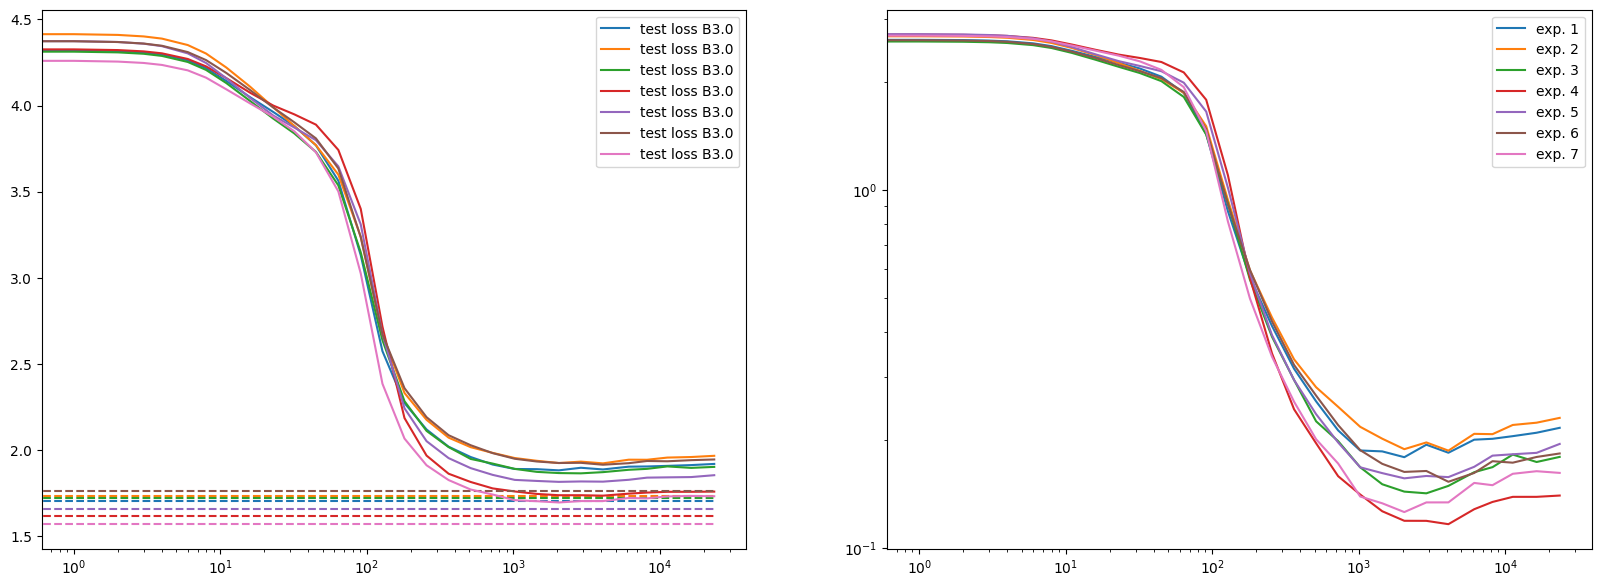

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(20,7))
test_loss_mean = []

for i in range(1, 8):
    dyn = dynamics[i]
    conf = configs[i]
    t = [d['t'] for d in dyn]
    test_loss = [d['testloss'] for d in dyn]
    ax[0].plot(t, test_loss, f'C{i-1}', label=f'test loss B{conf.beta}')
    test_loss_mean += test_loss
    ax[0].plot([d['t'] for d in dynamics[i]], [results[i]['output']['entropy'] for d in dynamics[i]], f'C{i-1}', linestyle='dashed')
    ax[1].plot(t,[d['testloss']-results[i]['output']['entropy'] for d in dyn], f'C{i-1}', label=f'exp. {i}')

ax[0].set_xscale('log')
ax[0].legend()
    
ax[1].set_yscale('log')
ax[1].set_xscale('log')

ax[1].legend()

/var/folders/gk/916zg_s91xs4ss4dk81l30n80000gn/T/ipykernel_69871/2397526839.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
/var/folders/gk/916zg_s91xs4ss4dk81l30n80000gn/T/ipykernel_69871/2397526839.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


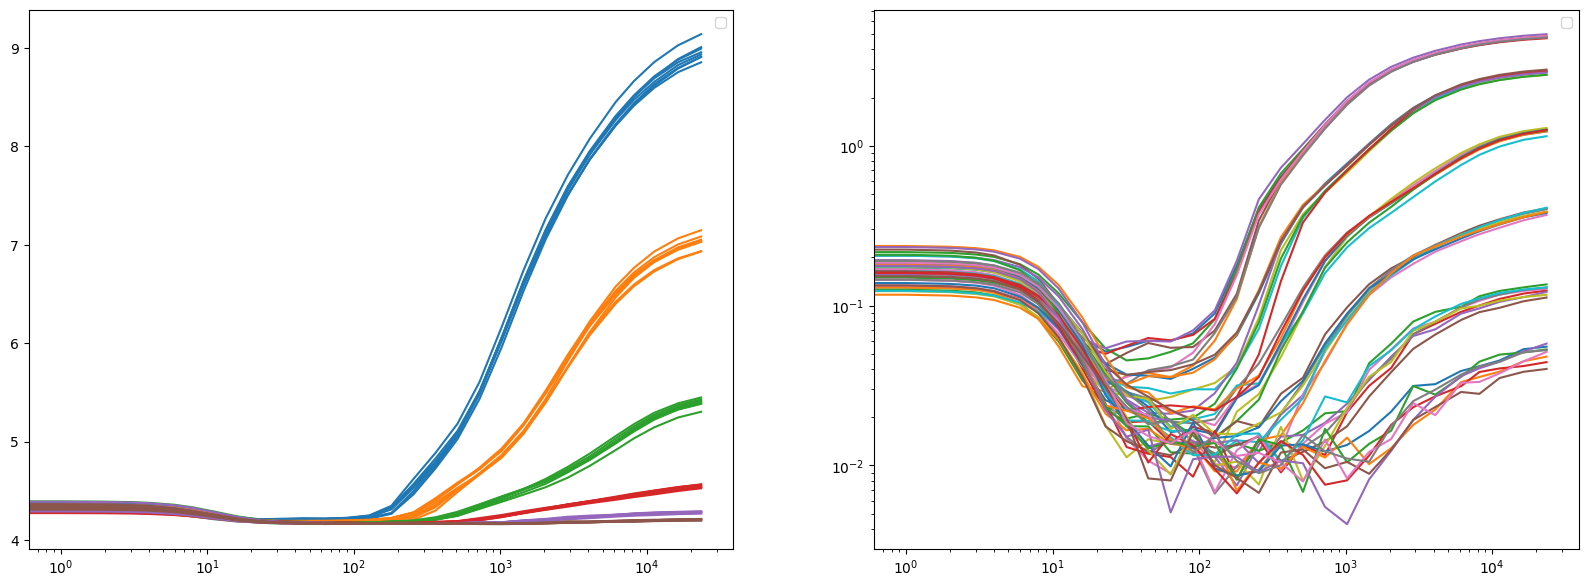

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(20,7))
beta = [0.2, 1, 3, 5]
nexp = 8
#path = f'RLM_results/'
path = f'RLM_results/Graphs_CLUSTER/Resultados_diferentes_betas_ts/'

for i_ts, train_size in enumerate([2**10, 2**11, 2**12, 2**13, 2**14, 2**15]):

    prefix = f'rlm64L1_b{beta[0]}_ts{train_size}'

    for i in range(1,nexp+1):

        results = torch.load(path+prefix+f'_{i}.pt', weights_only=False)
        dyn = results['output']['dynamics']
        entropy = results['output']['entropy']
        conf = results['config']
        t = [d['t'] for d in dyn]
        test_loss = [d['testloss'] for d in dyn]
        ax[0].plot(t, test_loss, f'C{i_ts}')
        # ax[0].plot(t, [entropy for d in dyn], f'C{i_ts}', linestyle='dashed')
        ax[1].plot(t,[d['testloss']-entropy for d in dyn])

ax[0].set_xscale('log')
ax[0].legend()
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].legend()

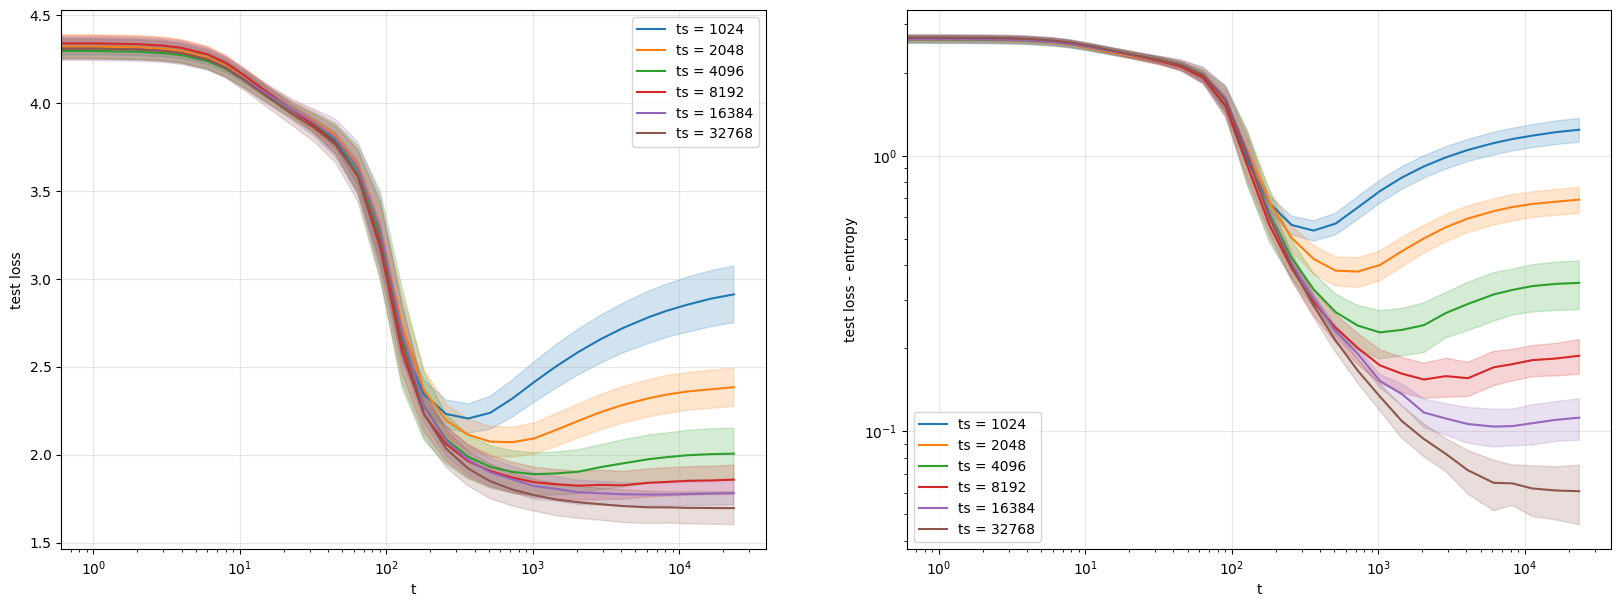

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(20,7))
beta = [0.2, 1, 3, 5]
nexp = 8
path = f'RLM_results/Graphs_CLUSTER/Resultados_diferentes_betas_ts/'
training_values = [2**10, 2**11, 2**12, 2**13, 2**14, 2**15]

for i_ts, train_size in enumerate(training_values):
    prefix = f'rlm64L1_b{beta[2]}_ts{train_size}'
    t_list, tl_list, diff_list = [], [], []
    for i in range(1, nexp+1):
        res = torch.load(path+prefix+f'_{i}.pt', map_location='cpu', weights_only=False)
        dyn = res['output']['dynamics']
        ent = res['output']['entropy']
        t = np.asarray([d['t'] for d in dyn], dtype=float)
        tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
        diff = tl - float(ent)
        t_list.append(t)
        tl_list.append(tl)
        diff_list.append(diff)
    if len(t_list)==0:
        continue
    L = min(len(x) for x in t_list)
    T = np.stack([x[:L] for x in t_list], axis=0)
    TL = np.stack([x[:L] for x in tl_list], axis=0)
    DI = np.stack([x[:L] for x in diff_list], axis=0)
    t_mean = T.mean(axis=0)
    tl_mean = TL.mean(axis=0)
    tl_std = TL.std(axis=0)
    di_mean = DI.mean(axis=0)
    di_std = DI.std(axis=0)
    c = f'C{i_ts}'
    ax[0].plot(t_mean, tl_mean, c, label=f'ts = {train_size}')
    ax[0].fill_between(t_mean, tl_mean-tl_std, tl_mean+tl_std, alpha=0.2, color=c)
    ax[1].plot(t_mean, di_mean, c, label=f'ts = {train_size}')
    ax[1].fill_between(t_mean, di_mean-di_std, di_mean+di_std, alpha=0.2, color=c)

ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].grid(True, alpha=0.3)
ax[1].grid(True, alpha=0.3)
ax[0].legend()
ax[1].legend()
plt.show()



/var/folders/gk/916zg_s91xs4ss4dk81l30n80000gn/T/ipykernel_69871/1777254165.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
/var/folders/gk/916zg_s91xs4ss4dk81l30n80000gn/T/ipykernel_69871/1777254165.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


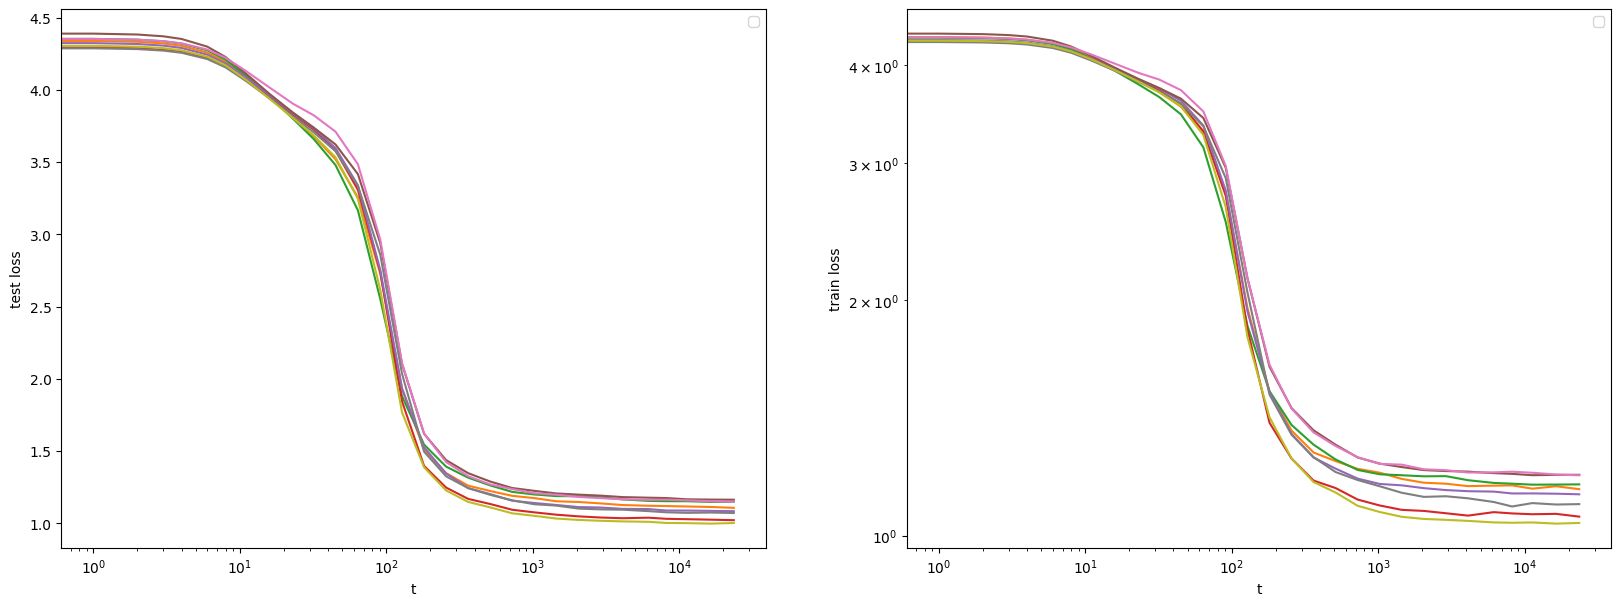

In [6]:
beta_value = 5
train_size = 2**15
nexp = 8                                   # número de repeticiones por experimento
path = 'RLM_results/Graphs_CLUSTER/Resultados_diferentes_betas_ts/'
prefix = f'rlm64L1_b{beta_value}_ts{train_size}'

fig, ax = plt.subplots(1, 2, figsize=(20,7))

for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + prefix + f'_{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie (según cómo se guardó)

    ax[0].plot([d['t'] for d in dyn], [d['trainloss'] for d in dyn], f'C{i}')
    ax[1].plot([d['t'] for d in dyn], [d['testloss'] for d in dyn], f'C{i}')

ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('train loss')
ax[0].legend()
ax[1].legend()

torch.Size([8, 30])


/var/folders/gk/916zg_s91xs4ss4dk81l30n80000gn/T/ipykernel_69871/950982654.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


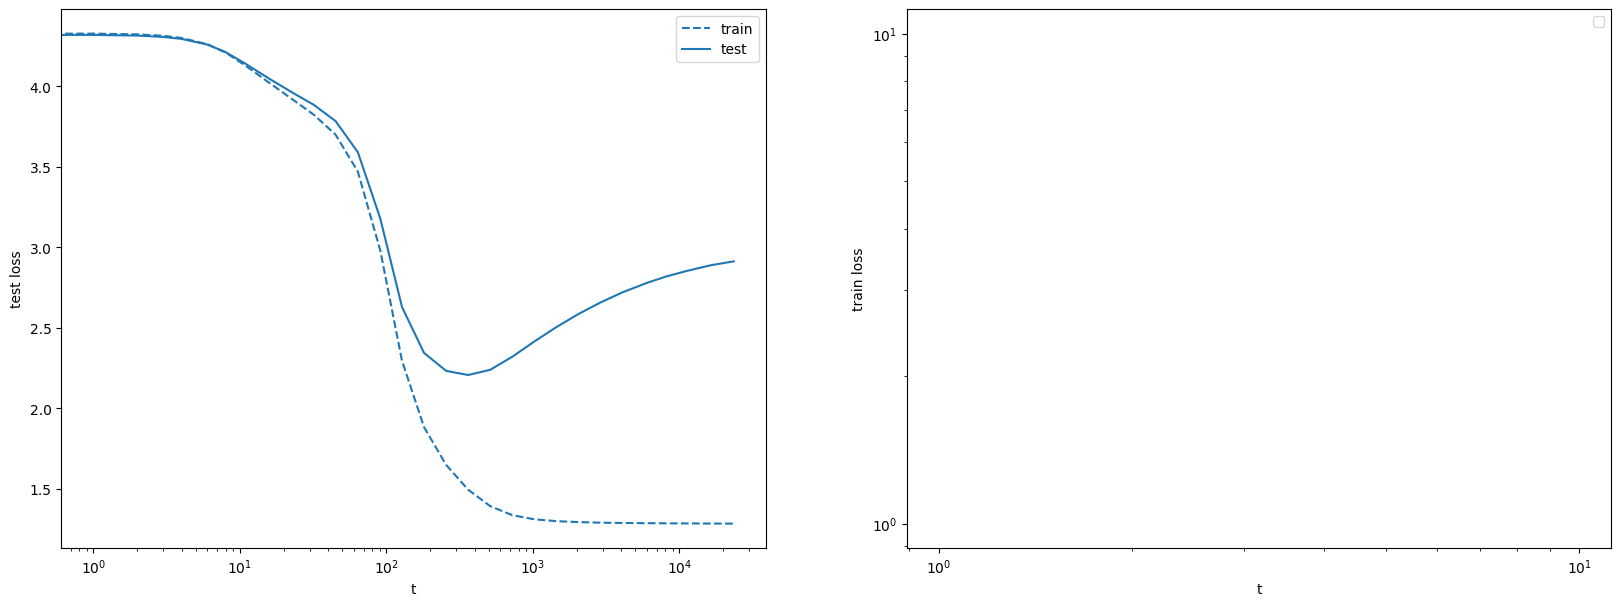

In [7]:
beta_value = 3
train_size = 2**10
nexp = 8                                   # número de repeticiones por experimento
path = 'RLM_results/Graphs_CLUSTER/Resultados_diferentes_betas_ts/'
prefix = f'rlm64L1_b{beta_value}_ts{train_size}'

fig, ax = plt.subplots(1, 2, figsize=(20,7))

trainloss_list = []
testloss_list = []

for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + prefix + f'_{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie (según cómo se guardó)

    time = [d['t'] for d in dyn]
    trainloss = torch.tensor([d['trainloss'] for d in dyn])
    trainloss_list.append(trainloss)
    testloss = torch.tensor([d['testloss'] for d in dyn])
    testloss_list.append(testloss)

trainloss = torch.stack(trainloss_list)
testloss = torch.stack(testloss_list)
print(testloss.size())
ax[0].plot(time, trainloss.mean(dim=0), f'C0', linestyle='dashed', label='train')
ax[0].plot(time, testloss.mean(dim=0), f'C0', label='test')

ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('train loss')
ax[0].legend()
ax[1].legend()

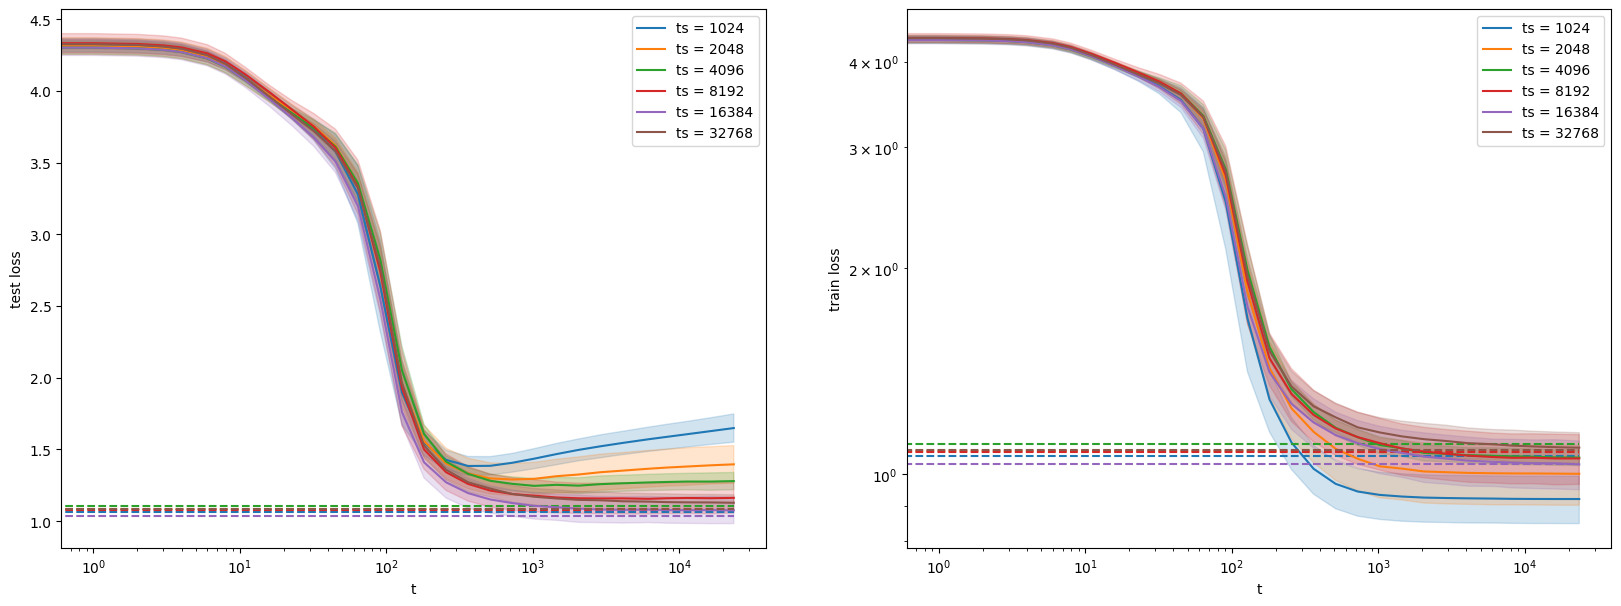

In [8]:
# Parámetros básicos
beta_list = [0.2, 1, 3, 5]                 # catálogo de betas para elegir
beta_value = beta_list[3]                  # aquí tomamos β=3 
nexp = 8                                   # número de repeticiones por experimento
path = 'RLM_results/Graphs_CLUSTER/Resultados_diferentes_betas_ts/'
training_values = [2**10,2**11,2**12,2**13,2**14, 2**15]           # lista de ts a comparar; 

# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

for i_ts, train_size in enumerate(training_values):
    # Prefijo del nombre de archivo siguiendo tu convención
    prefix = f'rlm64L1_b{beta_value}_ts{train_size}'

    # Acumuladores por run
    t_list = []      # tiempos por run (vector)
    trainloss_list = []     # train loss por run (vector)    
    tl_list = []     # test loss por run (vector)
    ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
    diff_list = []   # (test loss − entropy) por run (vector)

    # Recorremos runs 1..nexp
    for i in range(1, nexp+1):
        # Carga de cada repetición
        # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
        res = torch.load(path + prefix + f'_{i}.pt', map_location='cpu', weights_only=False)

        # Extraemos las series del dict
        dyn = res['output']['dynamics']     # lista de dicts por paso temporal
        ent = res['output']['entropy']      # escalar o serie (según cómo se guardó)

        # Convertimos a arrays NumPy para promediar
        t = np.asarray([d['t'] for d in dyn], dtype=float)
        trainloss = np.asarray([d['trainloss'] for d in dyn], dtype=float)
        tl = np.asarray([d['testloss'] for d in dyn], dtype=float)


        # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
        if np.ndim(ent) == 0:
            ent_vec = np.full_like(t, float(ent))
        else:
            ent_vec = np.asarray(ent, dtype=float)[:len(t)]

        # Guardamos cada run
        t_list.append(t)
        trainloss_list.append(trainloss)
        tl_list.append(tl)
        ent_list.append(ent_vec)
        diff_list.append(tl - ent_vec)

    # Si no hubo archivos válidos, pasa al siguiente ts
    if not t_list:
        continue

    # Alineamos longitudes: recortamos todas las series a la mínima longitud común L
    L = min(len(x) for x in t_list)
    T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
    TRAINLOSS  = np.stack([x[:L] for x in trainloss_list], axis=0)  # shape: [n_runs, L]
    TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
    ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
    DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]

    # Estadísticos por paso temporal (promedio y desviación estándar)
    t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
    trainloss_mean = TRAINLOSS.mean(axis=0)     # train loss promedio
    trainloss_std  = TRAINLOSS.std(axis=0)      # σ de train loss
    tl_mean = TL.mean(axis=0)     # test loss promedio
    tl_std  = TL.std(axis=0)      # σ de test loss
    ent_mean = ENT.mean(axis=0)   # entropía promedio
    di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
    di_std  = DI.std(axis=0)      # σ de (test loss − entropy)

    # Color consistente por ts
    c = f'C{i_ts}'

    # Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
    ax[0].plot(t_mean, tl_mean, c, label=f'ts = {train_size}')
    ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
    ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')

    # Panel derecho:  train loss ±σ y entropía promedio (línea punteada)
    ax[1].plot(t_mean, trainloss_mean, c, label=f'ts = {train_size}')
    ax[1].fill_between(t_mean, trainloss_mean - trainloss_std, trainloss_mean + trainloss_std, alpha=0.2, color=c)
    ax[1].plot(t_mean, ent_mean, c, linestyle='dashed')

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('train loss')

ax[0].legend()
ax[1].legend()


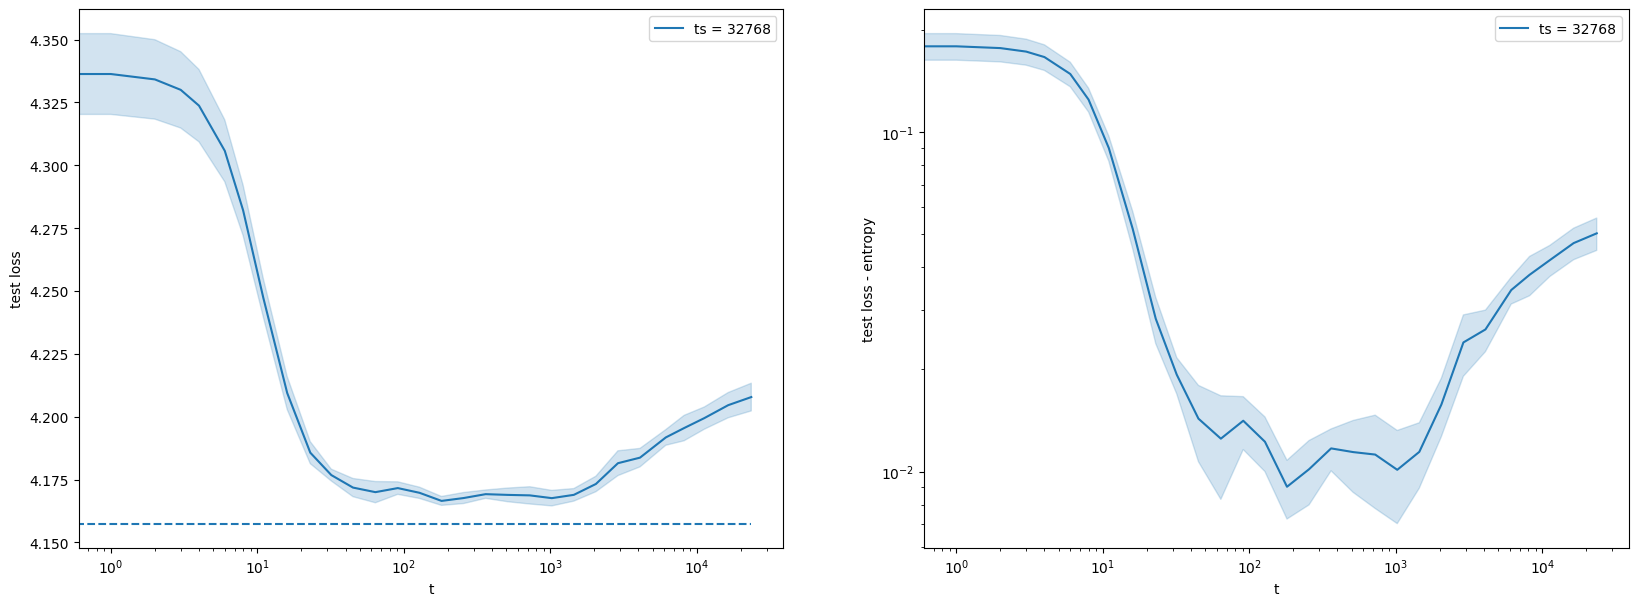

In [9]:


# Parámetros básicos
beta_list = [0.2, 1, 3, 5]                 # catálogo de betas para elegir
beta_value = beta_list[0]                  # aquí tomamos β=3 
nexp = 8                                   # número de repeticiones por experimento
path = 'RLM_results/Graphs_CLUSTER/Resultados_diferentes_betas_ts/'
training_values = [ 2**15]           # lista de ts a comparar; 

# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

for i_ts, train_size in enumerate(training_values):
    # Prefijo del nombre de archivo siguiendo tu convención
    prefix = f'rlm64L1_b{beta_value}_ts{train_size}'

    # Acumuladores por run
    t_list = []      # tiempos por run (vector)
    tl_list = []     # test loss por run (vector)
    ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
    diff_list = []   # (test loss − entropy) por run (vector)

    # Recorremos runs 1..nexp
    for i in range(1, nexp+1):
        # Carga de cada repetición
        # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
        res = torch.load(path + prefix + f'_{i}.pt', map_location='cpu', weights_only=False)

        # Extraemos las series del dict
        dyn = res['output']['dynamics']     # lista de dicts por paso temporal
        ent = res['output']['entropy']      # escalar o serie (según cómo se guardó)

        # Convertimos a arrays NumPy para promediar
        t = np.asarray([d['t'] for d in dyn], dtype=float)
        tl = np.asarray([d['testloss'] for d in dyn], dtype=float)

        # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
        if np.ndim(ent) == 0:
            ent_vec = np.full_like(t, float(ent))
        else:
            ent_vec = np.asarray(ent, dtype=float)[:len(t)]

        # Guardamos cada run
        t_list.append(t)
        tl_list.append(tl)
        ent_list.append(ent_vec)
        diff_list.append(tl - ent_vec)

    # Si no hubo archivos válidos, pasa al siguiente ts
    if not t_list:
        continue

    # Alineamos longitudes: recortamos todas las series a la mínima longitud común L
    L = min(len(x) for x in t_list)
    T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
    TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
    ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
    DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]

    # Estadísticos por paso temporal (promedio y desviación estándar)
    t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
    tl_mean = TL.mean(axis=0)     # test loss promedio
    tl_std  = TL.std(axis=0)      # σ de test loss
    ent_mean = ENT.mean(axis=0)   # entropía promedio
    di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
    di_std  = DI.std(axis=0)      # σ de (test loss − entropy)

    # Color consistente por ts
    c = f'C{i_ts}'

    # Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
    ax[0].plot(t_mean, tl_mean, c, label=f'ts = {train_size}')
    ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
    ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')

    # Panel derecho: (test loss − entropy) ±σ
    ax[1].plot(t_mean, di_mean, c, label=f'ts = {train_size}')
    ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()



1. Fix ts = 2**15, beta = 3, does the test-loss-vs-t curve change with embedding_dim, num_heads? Try embedding dim 64, 128, 256, and num_heads = 1, 2, 4;

2. Do the same at beta = 0.1 (less systematically, just to see if the loss doesn't go up anymore)

## Here we are plotting 3 values of embedding giving a fix number of head

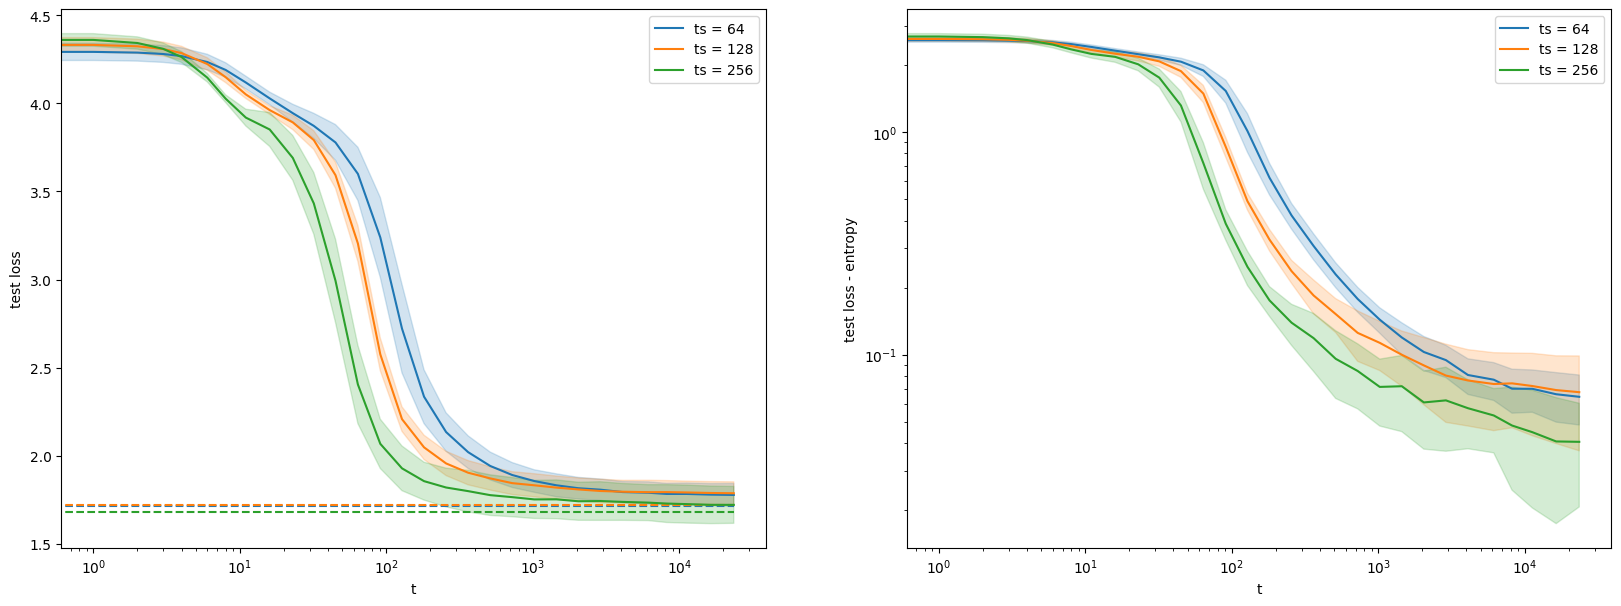

In [10]:


# Parámetros básicos
nh = [1, 2, 4]                 
nh_val = nh[0]                  
nexp = 8                                   # número de repeticiones por experimento
path = 'RLM_results/emb_nh/'
embs = [64, 128, 256]           # lista de ts a comparar; 

# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

for i_ts, emb in enumerate(embs):
    # Prefijo del nombre de archivo siguiendo tu convención
    prefix = f'rlm_64L1_b3_ts_{emb}_{nh_val}'

    # Acumuladores por run
    t_list = []      # tiempos por run (vector)
    tl_list = []     # test loss por run (vector)
    ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
    diff_list = []   # (test loss − entropy) por run (vector)

    # Recorremos runs 1..nexp
    for i in range(1, nexp+1):
        res = torch.load(path + prefix + f'{i}.pt', map_location='cpu', weights_only=False)

        # Extraemos las series del dict
        dyn = res['output']['dynamics']     # lista de dicts por paso temporal
        ent = res['output']['entropy']      # escalar o serie (según cómo se guardó)

        # Convertimos a arrays NumPy para promediar
        t = np.asarray([d['t'] for d in dyn], dtype=float)
        tl = np.asarray([d['testloss'] for d in dyn], dtype=float)

        # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
        if np.ndim(ent) == 0:
            ent_vec = np.full_like(t, float(ent))
        else:
            ent_vec = np.asarray(ent, dtype=float)[:len(t)]

        # Guardamos cada run
        t_list.append(t)
        tl_list.append(tl)
        ent_list.append(ent_vec)
        diff_list.append(tl - ent_vec)

    # Si no hubo archivos válidos, pasa al siguiente ts
    if not t_list:
        continue

    # Alineamos longitudes: recortamos todas las series a la mínima longitud común L
    L = min(len(x) for x in t_list)
    T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
    TL  = np.stack([x[:L] for x in tl_list], axis=0)  
    ENT = np.stack([x[:L] for x in ent_list], axis=0) 
    DI  = np.stack([x[:L] for x in diff_list], axis=0)

    # Estadísticos por paso temporal (promedio y desviación estándar)
    t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
    tl_mean = TL.mean(axis=0)     # test loss promedio
    tl_std  = TL.std(axis=0)      # σ de test loss
    ent_mean = ENT.mean(axis=0)   # entropía promedio
    di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
    di_std  = DI.std(axis=0)      # σ de (test loss − entropy)

    # Color
    c = f'C{i_ts}'

    # Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
    ax[0].plot(t_mean, tl_mean, c, label=f'ts = {emb}')
    ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
    ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')

    # Panel derecho: (test loss − entropy) ±σ
    ax[1].plot(t_mean, di_mean, c, label=f'ts = {emb}')
    ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()
plt.show()

## Here we are running 3 number of heads, fixing the number of embedding.

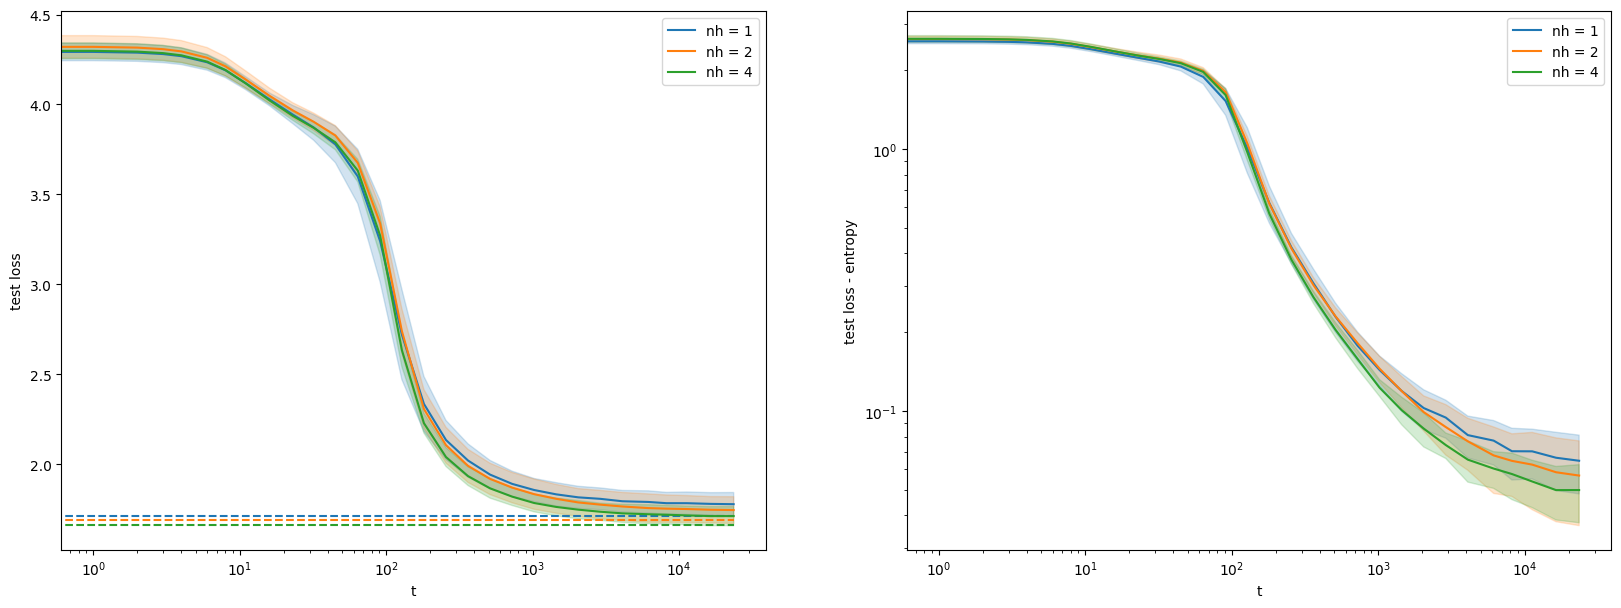

In [11]:


# Parámetros básicos
nh = [1, 2, 4]                 
nh_val = nh[2]                 
nexp = 8                                   # número de repeticiones por experimento
path = 'RLM_results/emb_nh/'
embs = [64, 128, 256]           # lista de ts a comparar; 
emb_val = embs[0] 

# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

for i_ts, nhs in enumerate(nh):
    # Prefijo del nombre de archivo siguiendo tu convención
    prefix = f'rlm_64L1_b3_ts_{emb_val}_{nhs}'

    # Acumuladores por run
    t_list = []      # tiempos por run (vector)
    tl_list = []     # test loss por run (vector)
    ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
    diff_list = []   # (test loss − entropy) por run (vector)

    # Recorremos runs 1..nexp
    for i in range(1, nexp+1):
        # Carga de cada repetición
        # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
        res = torch.load(path + prefix + f'{i}.pt', map_location='cpu', weights_only=False)

        # Extraemos las series del dict
        dyn = res['output']['dynamics']     # lista de dicts por paso temporal
        ent = res['output']['entropy']      # escalar o serie (según cómo se guardó)

        # Convertimos a arrays NumPy para promediar
        t = np.asarray([d['t'] for d in dyn], dtype=float)
        tl = np.asarray([d['testloss'] for d in dyn], dtype=float)

        # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
        if np.ndim(ent) == 0:
            ent_vec = np.full_like(t, float(ent))
        else:
            ent_vec = np.asarray(ent, dtype=float)[:len(t)]

        # Guardamos cada run
        t_list.append(t)
        tl_list.append(tl)
        ent_list.append(ent_vec)
        diff_list.append(tl - ent_vec)

    # Si no hubo archivos válidos, pasa al siguiente ts
    if not t_list:
        continue

    # Alineamos longitudes: recortamos todas las series a la mínima longitud común L
    L = min(len(x) for x in t_list)
    T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
    TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
    ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
    DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]

    # Estadísticos por paso temporal (promedio y desviación estándar)
    t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
    tl_mean = TL.mean(axis=0)     # test loss promedio
    tl_std  = TL.std(axis=0)      # σ de test loss
    ent_mean = ENT.mean(axis=0)   # entropía promedio
    di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
    di_std  = DI.std(axis=0)      # σ de (test loss − entropy)

    # Color consistente por ts
    c = f'C{i_ts}'

    # Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
    ax[0].plot(t_mean, tl_mean, c, label=f'nh = {nhs}')
    ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
    ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')

    # Panel derecho: (test loss − entropy) ±σ
    ax[1].plot(t_mean, di_mean, c, label=f'nh = {nhs}')
    ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

## Here we are maintaining fix Emb * NH = 256

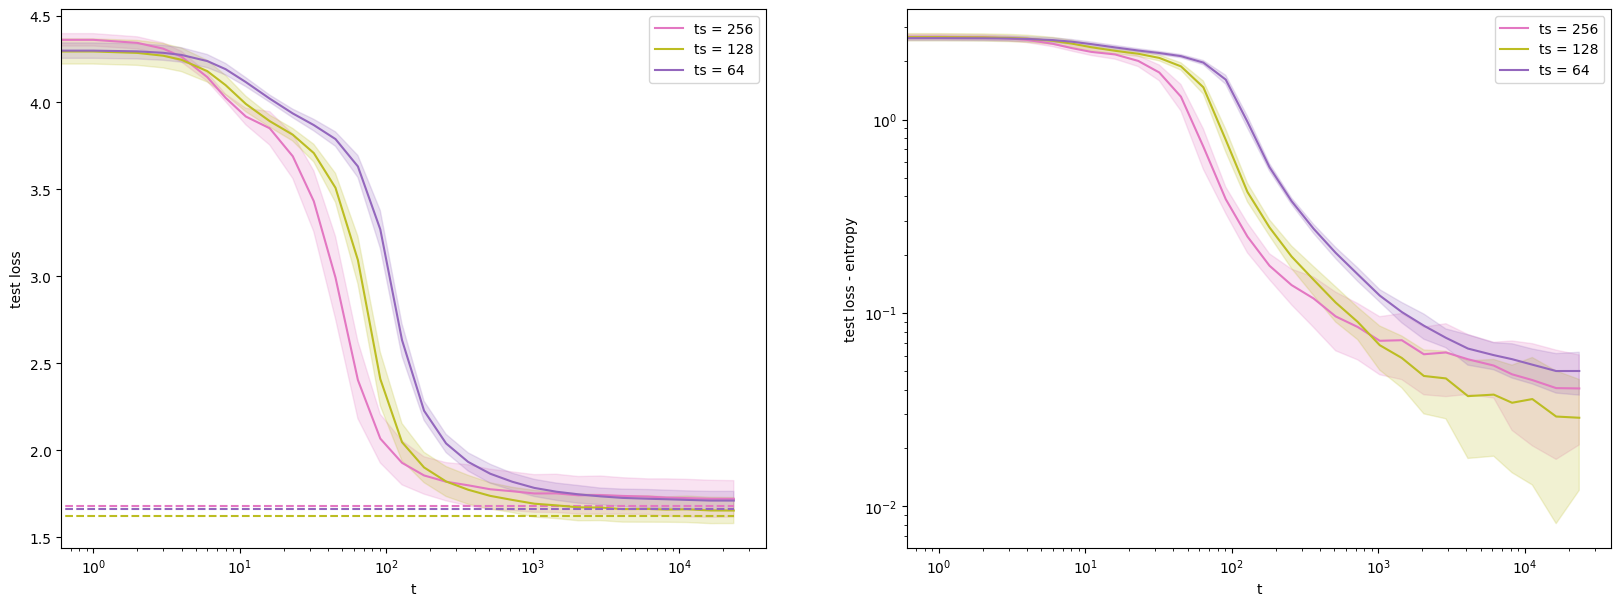

In [12]:
# Parámetros básicos
nh = [1, 2, 4]                 
#nh_val = nh[0]                 
nexp = 8                                   # número de repeticiones por experimento
path = 'RLM_results/emb_nh/'
embs = [256, 128, 64]           # lista de ts a comparar; 
#emb_val = embs[0] 

# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

for j in range(3):
    # Prefijo del nombre de archivo siguiendo tu convención
    prefix = f'rlm_64L1_b3_ts_{embs[j]}_{nh[j]}'

    # Acumuladores por run
    t_list = []      # tiempos por run (vector)
    tl_list = []     # test loss por run (vector)
    ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
    diff_list = []   # (test loss − entropy) por run (vector)

    # Recorremos runs 1..nexp
    for i in range(1, nexp+1):
        # Carga de cada repetición
        # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
        res = torch.load(path + prefix + f'{i}.pt', map_location='cpu', weights_only=False)

        # Extraemos las series del dict
        dyn = res['output']['dynamics']     # lista de dicts por paso temporal
        ent = res['output']['entropy']      # escalar o serie (según cómo se guardó)

        # Convertimos a arrays NumPy para promediar
        t = np.asarray([d['t'] for d in dyn], dtype=float)
        tl = np.asarray([d['testloss'] for d in dyn], dtype=float)

        # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
        if np.ndim(ent) == 0:
            ent_vec = np.full_like(t, float(ent))
        else:
            ent_vec = np.asarray(ent, dtype=float)[:len(t)]

        # Guardamos cada run
        t_list.append(t)
        tl_list.append(tl)
        ent_list.append(ent_vec)
        diff_list.append(tl - ent_vec)

    # Si no hubo archivos válidos, pasa al siguiente ts
    if not t_list:
        continue

    # Alineamos longitudes: recortamos todas las series a la mínima longitud común L
    L = min(len(x) for x in t_list)
    T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
    TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
    ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
    DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]

    # Estadísticos por paso temporal (promedio y desviación estándar)
    t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
    tl_mean = TL.mean(axis=0)     # test loss promedio
    tl_std  = TL.std(axis=0)      # σ de test loss
    ent_mean = ENT.mean(axis=0)   # entropía promedio
    di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
    di_std  = DI.std(axis=0)      # σ de (test loss − entropy)

    # Color consistente por ts
    c = f'C{embs[j]}'

    # Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
    ax[0].plot(t_mean, tl_mean, c, label=f'ts = {embs[j]}')
    ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
    ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')

    # Panel derecho: (test loss − entropy) ±σ
    ax[1].plot(t_mean, di_mean, c, label=f'ts = {embs[j]}')
    ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()
plt.show()

## Graphs for proving scalability, only for same number of embeddings per head.

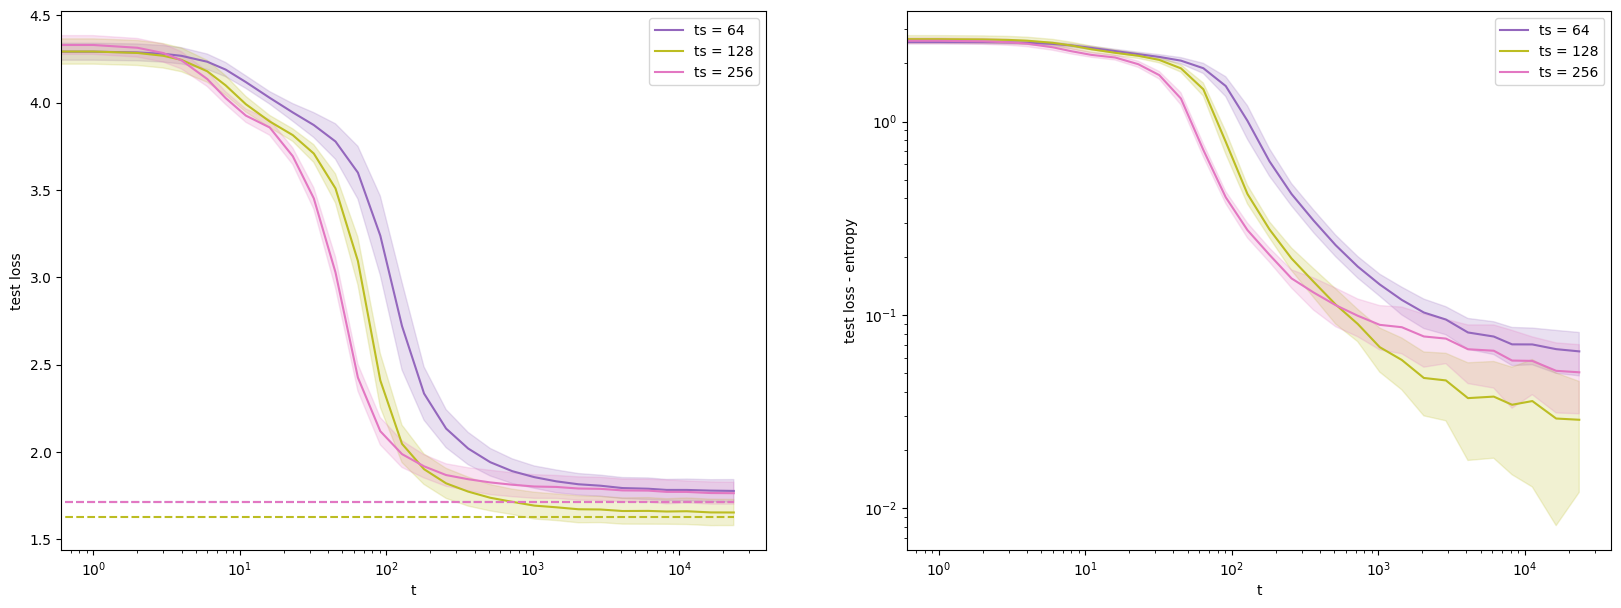

In [13]:
# Parámetros básicos
nh = [1,2,4]                 
#nh_val = nh[0]                 
nexp = 8                                   # número de repeticiones por experimento
path = 'RLM_results/emb_nh/'
embs = [64,128, 256]           # lista de ts a comparar; 
#emb_val = embs[0] 

# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

for j in range(len(embs)):
    # Prefijo del nombre de archivo siguiendo tu convención
    prefix = f'rlm_64L1_b3_ts_{embs[j]}_{nh[j]}'

    # Acumuladores por run
    t_list = []      # tiempos por run (vector)
    tl_list = []     # test loss por run (vector)
    ent_list = []    # entropía por run (vector
    diff_list = []   # (test loss − entropy) por run (vector)

    # Recorremos runs 1..nexp
    for i in range(1, nexp+1):
        # Carga de cada repetición
        
        res = torch.load(path + prefix + f'{i}.pt', map_location='cpu', weights_only=False)

        # Extraemos las series del dict
        dyn = res['output']['dynamics']     # lista de dicts por paso temporal
        ent = res['output']['entropy']      # escalar o serie 

        # Convertimos a arrays NumPy para promediar
        t = np.asarray([d['t'] for d in dyn], dtype=float)
        tl = np.asarray([d['testloss'] for d in dyn], dtype=float)

        # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
        if np.ndim(ent) == 0:
            ent_vec = np.full_like(t, float(ent))
        else:
            ent_vec = np.asarray(ent, dtype=float)[:len(t)]

        # Guardamos cada run
        t_list.append(t)
        tl_list.append(tl)
        ent_list.append(ent_vec)
        diff_list.append(tl - ent_vec)

    
    if not t_list:
        continue

    # Alineamos longitudes: recortamos todas las series a la mínima longitud común L
    L = min(len(x) for x in t_list)
    T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
    TL  = np.stack([x[:L] for x in tl_list], axis=0)  
    ENT = np.stack([x[:L] for x in ent_list], axis=0) 
    DI  = np.stack([x[:L] for x in diff_list], axis=0)

    # Estadísticos por paso temporal (promedio y desviación estándar)
    t_mean  = T.mean(axis=0)      # tiempo promedio 
    tl_mean = TL.mean(axis=0)     # test loss promedio
    tl_std  = TL.std(axis=0)      # σ de test loss
    ent_mean = ENT.mean(axis=0)   # entropía promedio
    di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
    di_std  = DI.std(axis=0)      # σ de (test loss − entropy)

    # Color consistente por ts
    c = f'C{embs[j]}'
    
    '''
    if j ==2:
        t_mean  = t_mean * 3.6      # tiempo promedio 
        tl_mean = tl_mean * 1    # test loss promedio

    if j ==1:
        t_mean  = t_mean * 2.67      # tiempo promedio 
        tl_mean = tl_mean * 1    # test loss promedio

    if j ==0:
        t_mean  = t_mean * 1.4     # tiempo promedio 
        tl_mean = tl_mean * 1    # test loss promedio
    '''

    # Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
    ax[0].plot(t_mean, tl_mean, c, label=f'ts = {embs[j]}')
    ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
    ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')

    # Panel derecho: (test loss − entropy) ±σ
    ax[1].plot(t_mean, di_mean, c, label=f'ts = {embs[j]}')
    ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

## Prove scalability for embedding per head.

## Betas around transition point. Learning curves.

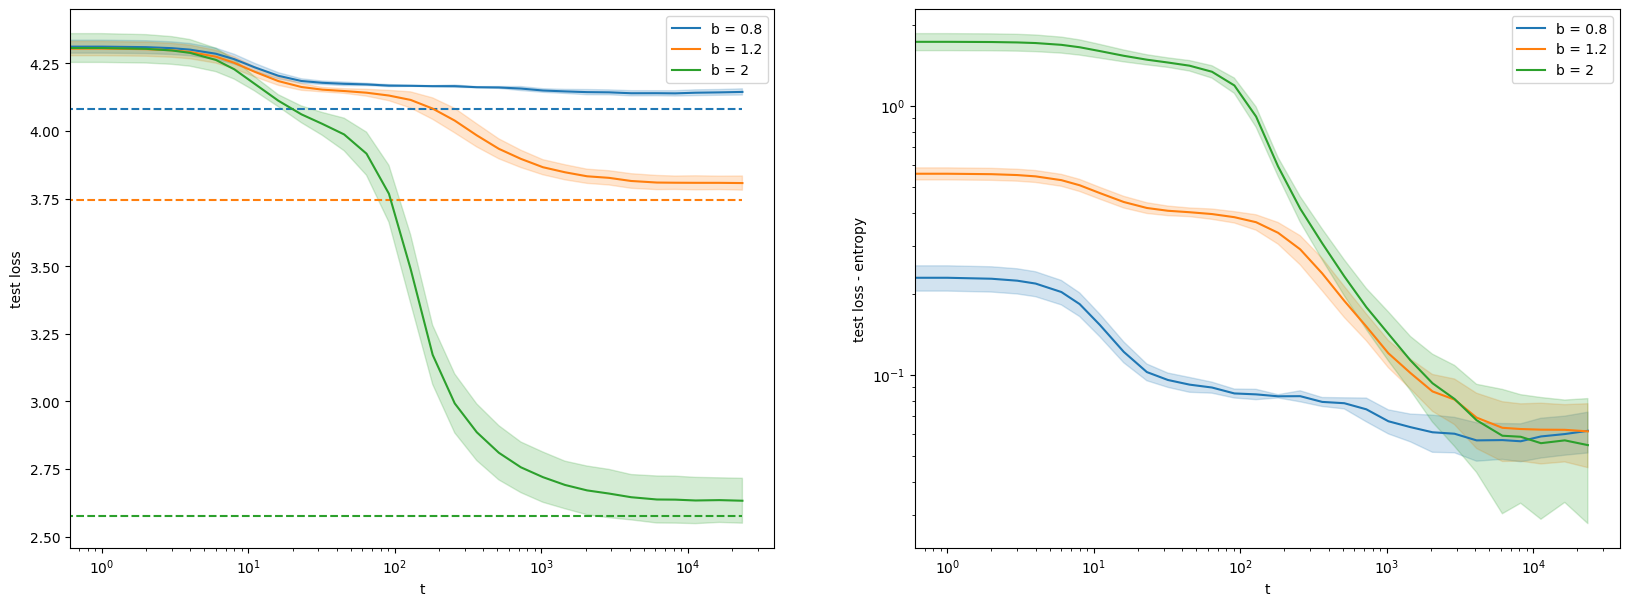

In [14]:
# Parámetros básicos
beta_list =[0.8,1.2,2]                 # Valores β
beta_value = beta_list[0]                  #Seleccionamos beta
nexp = 8                                   # Experimentos
path = 'RLM_results/changing_beta/'
training_values =[2**15,2**16, 2**17]           # lista de ts a comparar; 
train_value = training_values[0]
batch_size= 64
nh=1
emb_dim = 128


# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

for i_ts, betas in enumerate(beta_list):
    # Prefijo del nombre de archivo siguiendo tu convención
    prefix = f'rlm_64L1_b{betas}_ts{train_value}_{batch_size}_{nh}_{emb_dim}_'

    # Acumuladores por run
    t_list = []      # tiempos por run (vector)
    tl_list = []     # test loss por run (vector)
    ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
    diff_list = []   # (test loss − entropy) por run (vector)

    # Recorremos runs 1..nexp
    for i in range(1, nexp+1):
        # Carga de cada repetición
        # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
        res = torch.load(path + prefix + f'{i}.pt', map_location='cpu', weights_only=False)

        # Extraemos las series del dict
        dyn = res['output']['dynamics']     # lista de dicts por paso temporal
        ent = res['output']['entropy']      # escalar o serie (según cómo se guardó)

        # Convertimos a arrays NumPy para promediar
        t = np.asarray([d['t'] for d in dyn], dtype=float)
        tl = np.asarray([d['testloss'] for d in dyn], dtype=float)

        # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
        if np.ndim(ent) == 0:
            ent_vec = np.full_like(t, float(ent))
        else:
            ent_vec = np.asarray(ent, dtype=float)[:len(t)]

        # Guardamos cada run
        t_list.append(t)
        tl_list.append(tl)
        ent_list.append(ent_vec)
        diff_list.append(tl - ent_vec)

    # Si no hubo archivos válidos, pasa al siguiente ts
    if not t_list:
        continue

    # Alineamos longitudes: recortamos todas las series a la mínima longitud común L
    L = min(len(x) for x in t_list)
    T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
    TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
    ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
    DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]

    # Estadísticos por paso temporal (promedio y desviación estándar)
    t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
    tl_mean = TL.mean(axis=0)     # test loss promedio
    tl_std  = TL.std(axis=0)      # σ de test loss
    ent_mean = ENT.mean(axis=0)   # entropía promedio
    di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
    di_std  = DI.std(axis=0)      # σ de (test loss − entropy)

    # Color consistente por ts
    c = f'C{i_ts}'
    
    # Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
    ax[0].plot(t_mean, tl_mean, c, label=f'b = {betas}')
    ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
    ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')

    # Panel derecho: (test loss − entropy) ±σ
    ax[1].plot(t_mean, di_mean, c, label=f'b = {betas}')
    ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()


## Cutting the Graphs

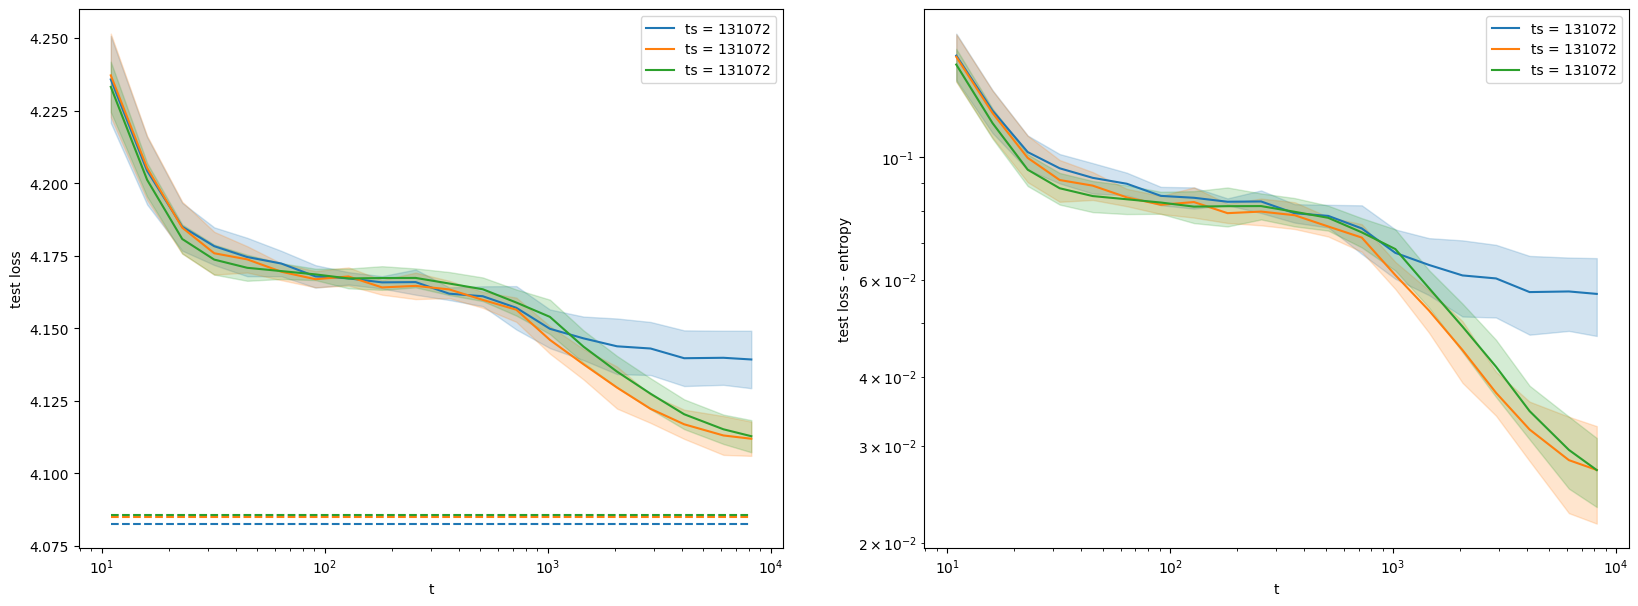

In [15]:
# Parámetros básicos
beta_list =[0.8,1.2,2]                 # Valores β
beta_value = beta_list[0]                  #Seleccionamos beta
nexp = 8                                   # Experimentos
path = 'RLM_results/changing_beta/'
training_values =[2**15,2**16, 2**17]           # lista de ts a comparar; 
batch_size= 64
nh=1
emb_dim = 128


# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

for i_ts, train_size in enumerate(training_values):
    # Prefijo del nombre de archivo siguiendo tu convención
    prefix = f'rlm_64L1_b{beta_value}_ts{train_size}_{batch_size}_{nh}_{emb_dim}_'

    # Acumuladores por run
    t_list = []      # tiempos por run (vector)
    tl_list = []     # test loss por run (vector)
    ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
    diff_list = []   # (test loss − entropy) por run (vector)

    # Recorremos runs 1..nexp
    for i in range(1, nexp+1):
        # Carga de cada repetición
        # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
        res = torch.load(path + prefix + f'{i}.pt', map_location='cpu', weights_only=False)

        # Extraemos las series del dict
        dyn = res['output']['dynamics']     # lista de dicts por paso temporal
        ent = res['output']['entropy']      # escalar o serie (según cómo se guardó)

        # Convertimos a arrays NumPy para promediar
        t = np.asarray([d['t'] for d in dyn], dtype=float)
        tl = np.asarray([d['testloss'] for d in dyn], dtype=float)

        # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
        if np.ndim(ent) == 0:
            ent_vec = np.full_like(t, float(ent))
        else:
            ent_vec = np.asarray(ent, dtype=float)[:len(t)]

        # Guardamos cada run
        t_list.append(t)
        tl_list.append(tl)
        ent_list.append(ent_vec)
        diff_list.append(tl - ent_vec)

    # Si no hubo archivos válidos, pasa al siguiente ts
    if not t_list:
        continue

    # Alineamos longitudes: recortamos todas las series a la mínima longitud común L
    L = min(len(x) for x in t_list)
    T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
    TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
    ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
    DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]

    # Estadísticos por paso temporal (promedio y desviación estándar)
    t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
    tl_mean = TL.mean(axis=0)     # test loss promedio
    tl_std  = TL.std(axis=0)      # σ de test loss
    ent_mean = ENT.mean(axis=0)   # entropía promedio
    di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
    di_std  = DI.std(axis=0)      # σ de (test loss − entropy)

    # Color consistente por ts
    c = f'C{i_ts}'
    # Filtrar el rango deseado en base a t_mean
    mask = (t_mean >= 10) & (t_mean <= 1e4)

    # Aplicar la máscara a todos los vectores que se grafican
    t_plot     = t_mean[mask]
    tl_plot    = tl_mean[mask]
    tl_std_plot = tl_std[mask]
    ent_plot   = ent_mean[mask]
    di_plot    = di_mean[mask]
    di_std_plot = di_std[mask]
    
    ax[0].plot(t_plot, tl_plot, c, label=f'ts = {training_values[j]}')
    ax[0].fill_between(t_plot, tl_plot - tl_std_plot, tl_plot + tl_std_plot, alpha=0.2, color=c)
    ax[0].plot(t_plot, ent_plot, c, linestyle='dashed')

    # Panel derecho: (test loss − entropy) ±σ
    ax[1].plot(t_plot, di_plot, c, label=f'ts = {training_values[j]}')
    ax[1].fill_between(t_plot, di_plot - di_std_plot, di_plot + di_std_plot, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()


## Graphs

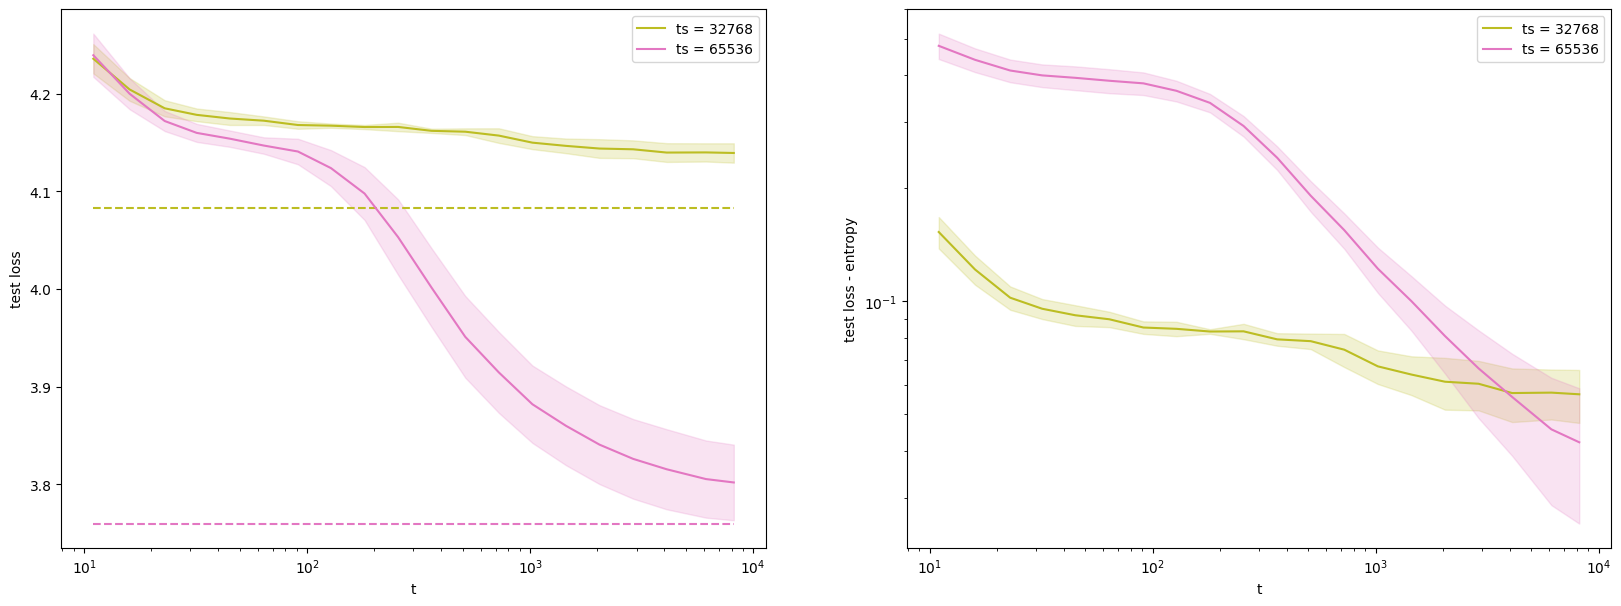

In [16]:
# Parámetros básicos
beta_list =[0.8,1.2,2]                 
#nh_val = nh[0]                 
nexp = 8                                   # número de repeticiones por experimento
path = 'RLM_results/changing_beta/'
training_values =[2**15,2**16, 2**17]           # lista de ts a comparar; 
#emb_val = embs[0] 

# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

for j in range(2):
    # Prefijo del nombre de archivo siguiendo tu convención
    prefix = f'rlm_64L1_b{beta_list[j]}_ts{training_values[j]}_{batch_size}_{nh}_{emb_dim}_'

    # Acumuladores por run
    t_list = []      # tiempos por run (vector)
    tl_list = []     # test loss por run (vector)
    ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
    diff_list = []   # (test loss − entropy) por run (vector)

    # Recorremos runs 1..nexp
    for i in range(1, nexp+1):
        # Carga de cada repetición
        # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
        res = torch.load(path + prefix + f'{i}.pt', map_location='cpu', weights_only=False)

        # Extraemos las series del dict
        dyn = res['output']['dynamics']     # lista de dicts por paso temporal
        ent = res['output']['entropy']      # escalar o serie (según cómo se guardó)

        # Convertimos a arrays NumPy para promediar
        t = np.asarray([d['t'] for d in dyn], dtype=float)
        tl = np.asarray([d['testloss'] for d in dyn], dtype=float)

        # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
        if np.ndim(ent) == 0:
            ent_vec = np.full_like(t, float(ent))
        else:
            ent_vec = np.asarray(ent, dtype=float)[:len(t)]

        # Guardamos cada run
        t_list.append(t)
        tl_list.append(tl)
        ent_list.append(ent_vec)
        diff_list.append(tl - ent_vec)

    # Si no hubo archivos válidos, pasa al siguiente ts
    if not t_list:
        continue

    # Alineamos longitudes: recortamos todas las series a la mínima longitud común L
    L = min(len(x) for x in t_list)
    T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
    TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
    ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
    DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]

    # Estadísticos por paso temporal (promedio y desviación estándar)
    t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
    tl_mean = TL.mean(axis=0)     # test loss promedio
    tl_std  = TL.std(axis=0)      # σ de test loss
    ent_mean = ENT.mean(axis=0)   # entropía promedio
    di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
    di_std  = DI.std(axis=0)      # σ de (test loss − entropy)

    # Color consistente por ts
    c = f'C{training_values[j]}'
    # Filtrar el rango deseado en base a t_mean
    window = (t_mean >= 10) & (t_mean <= 1e4)

    # Aplicar la máscara a todos los vectores que se grafican
    t_plot     = t_mean[window]
    tl_plot    = tl_mean[window]
    tl_std_plot = tl_std[window]
    ent_plot   = ent_mean[window]
    di_plot    = di_mean[window]
    di_std_plot = di_std[window]

    # Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
    #ax[0].plot(t_mean, tl_mean, c, label=f'ts = {training_values[j]}')
    #ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
    #ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
    # Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
    ax[0].plot(t_plot, tl_plot, c, label=f'ts = {training_values[j]}')
    ax[0].fill_between(t_plot, tl_plot - tl_std_plot, tl_plot + tl_std_plot, alpha=0.2, color=c)
    ax[0].plot(t_plot, ent_plot, c, linestyle='dashed')

    # Panel derecho: (test loss − entropy) ±σ
    ax[1].plot(t_plot, di_plot, c, label=f'ts = {training_values[j]}')
    ax[1].fill_between(t_plot, di_plot - di_std_plot, di_plot + di_std_plot, alpha=0.2, color=c)

    # Panel derecho: (test loss − entropy) ±σ
    #ax[1].plot(t_mean, di_mean, c, label=f'ts = {training_values[j]}')
    #ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

## Scalling test

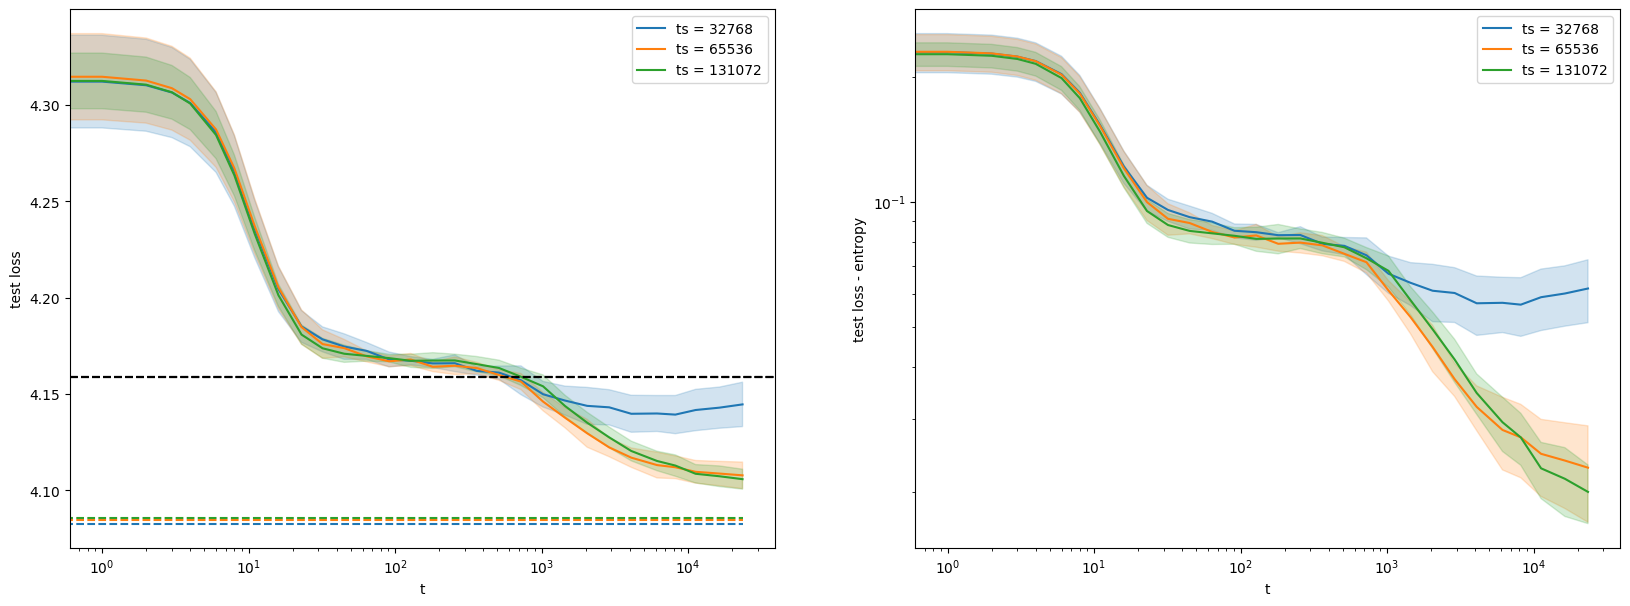

In [13]:
# Parámetros básicos
beta_list =[0.8,1.2,2]                 # Valores β
beta_value = beta_list[0]                  #Seleccionamos beta
nexp = 8                                   # Experimentos
path = 'RLM_results/changing_beta/'
training_values =[2**15,2**16, 2**17]           # lista de ts a comparar; 
batch_size= 64
nh=1
emb_dim = 128


# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

for i_ts, train_size in enumerate(training_values):
    # Prefijo del nombre de archivo siguiendo tu convención
    prefix = f'rlm_64L1_b{beta_value}_ts{train_size}_{batch_size}_{nh}_{emb_dim}_'

    # Acumuladores por run
    t_list = []      # tiempos por run (vector)
    tl_list = []     # test loss por run (vector)
    ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
    diff_list = []   # (test loss − entropy) por run (vector)

    # Recorremos runs 1..nexp
    for i in range(1, nexp+1):
        # Carga de cada repetición
        # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
        res = torch.load(path + prefix + f'{i}.pt', map_location='cpu', weights_only=False)

        # Extraemos las series del dict
        dyn = res['output']['dynamics']     # lista de dicts por paso temporal
        ent = res['output']['entropy']      # escalar o serie (según cómo se guardó)

        # Convertimos a arrays NumPy para promediar
        t = np.asarray([d['t'] for d in dyn], dtype=float)
        tl = np.asarray([d['testloss'] for d in dyn], dtype=float)

        # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
        if np.ndim(ent) == 0:
            ent_vec = np.full_like(t, float(ent))
        else:
            ent_vec = np.asarray(ent, dtype=float)[:len(t)]

        # Guardamos cada run
        t_list.append(t)
        tl_list.append(tl)
        ent_list.append(ent_vec)
        diff_list.append(tl - ent_vec)

    # Si no hubo archivos válidos, pasa al siguiente ts
    if not t_list:
        continue

    # Alineamos longitudes: recortamos todas las series a la mínima longitud común L
    L = min(len(x) for x in t_list)
    T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
    TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
    ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
    DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]

    # Estadísticos por paso temporal (promedio y desviación estándar)
    t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
    tl_mean = TL.mean(axis=0)     # test loss promedio
    tl_std  = TL.std(axis=0)      # σ de test loss
    ent_mean = ENT.mean(axis=0)   # entropía promedio
    di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
    di_std  = DI.std(axis=0)      # σ de (test loss − entropy)

    # Color consistente por ts
    c = f'C{i_ts}'
    a = math.log(64)
    ent_scalar = a

    # Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
    ax[0].plot(t_mean, tl_mean, c, label=f'ts = {train_size}')
    ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
    ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
    
    ax[0].axhline(float(ent_scalar), color='k', linestyle='dashed')
    

    # Panel derecho: (test loss − entropy) ±σ
    ax[1].plot(t_mean, di_mean, c, label=f'ts = {train_size}')
    ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

## BETAS Test 

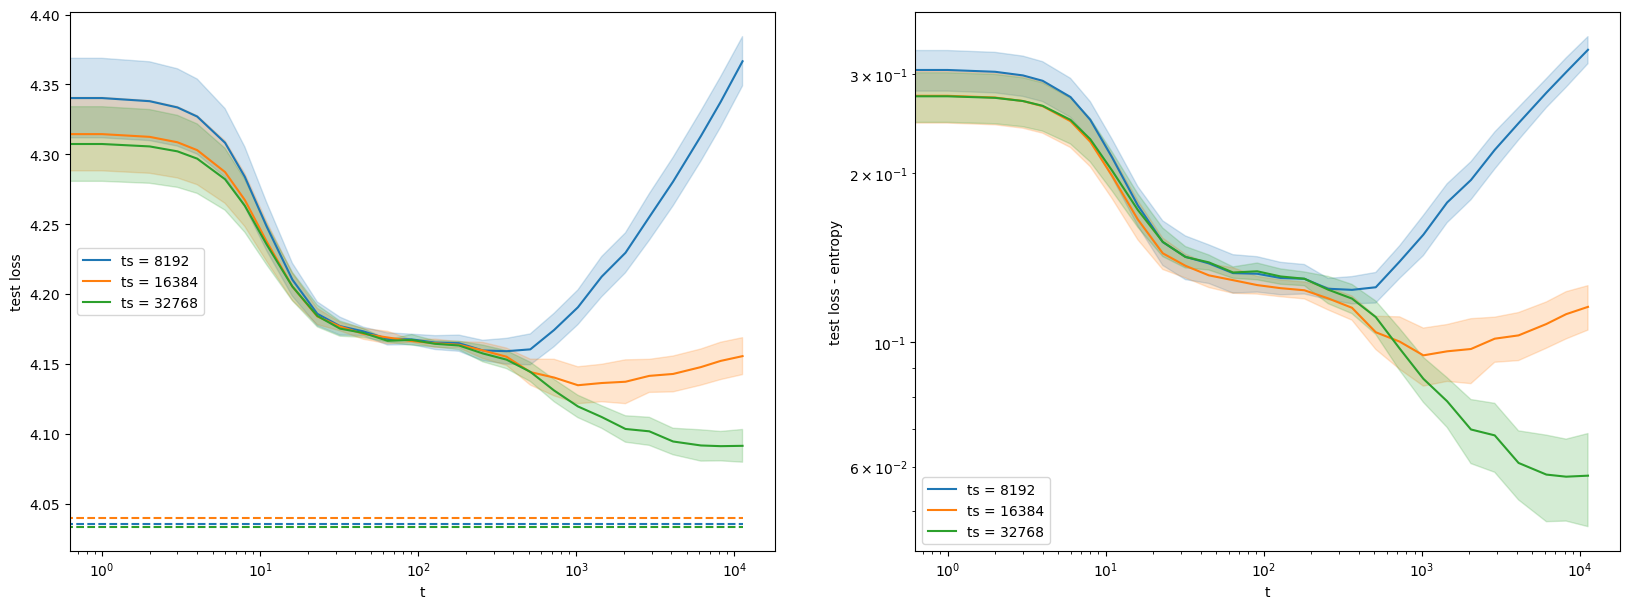

In [18]:
# Parámetros básicos
beta_list =[0.9,1.0,1.1]                 # Valores β
beta_value = beta_list[0]                  #Seleccionamos beta
nexp = 8                                   # Experimentos
path = 'RLM_results/B_09_10_11/'
training_values =[2**13,2**14,2**15]           # lista de ts a comparar; 
batch_size= 64
nh=1
emb_dim = 128


# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

for i_ts, train_size in enumerate(training_values):
    # Prefijo del nombre de archivo siguiendo tu convención
    prefix = f'rlm_64L1_b{beta_value}_ts{train_size}_{batch_size}_{nh}_{emb_dim}_'

    # Acumuladores por run
    t_list = []      # tiempos por run (vector)
    tl_list = []     # test loss por run (vector)
    ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
    diff_list = []   # (test loss − entropy) por run (vector)

    # Recorremos runs 1..nexp
    for i in range(1, nexp+1):
        # Carga de cada repetición
        # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
        res = torch.load(path + prefix + f'{i}.pt', map_location='cpu', weights_only=False)

        # Extraemos las series del dict
        dyn = res['output']['dynamics']     # lista de dicts por paso temporal
        ent = res['output']['entropy']      # escalar o serie (según cómo se guardó)

        # Convertimos a arrays NumPy para promediar
        t = np.asarray([d['t'] for d in dyn], dtype=float)
        tl = np.asarray([d['testloss'] for d in dyn], dtype=float)

        # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
        if np.ndim(ent) == 0:
            ent_vec = np.full_like(t, float(ent))
        else:
            ent_vec = np.asarray(ent, dtype=float)[:len(t)]

        # Guardamos cada run
        t_list.append(t)
        tl_list.append(tl)
        ent_list.append(ent_vec)
        diff_list.append(tl - ent_vec)

    # Si no hubo archivos válidos, pasa al siguiente ts
    if not t_list:
        continue

    # Alineamos longitudes: recortamos todas las series a la mínima longitud común L
    L = min(len(x) for x in t_list)
    T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
    TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
    ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
    DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]

    # Estadísticos por paso temporal (promedio y desviación estándar)
    t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
    tl_mean = TL.mean(axis=0)     # test loss promedio
    tl_std  = TL.std(axis=0)      # σ de test loss
    ent_mean = ENT.mean(axis=0)   # entropía promedio
    di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
    di_std  = DI.std(axis=0)      # σ de (test loss − entropy)

    # Color consistente por ts
    c = f'C{i_ts}'
    
    # Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
    ax[0].plot(t_mean, tl_mean, c, label=f'ts = {train_size}')
    ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
    ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')

    # Panel derecho: (test loss − entropy) ±σ
    ax[1].plot(t_mean, di_mean, c, label=f'ts = {train_size}')
    ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

## Large Test

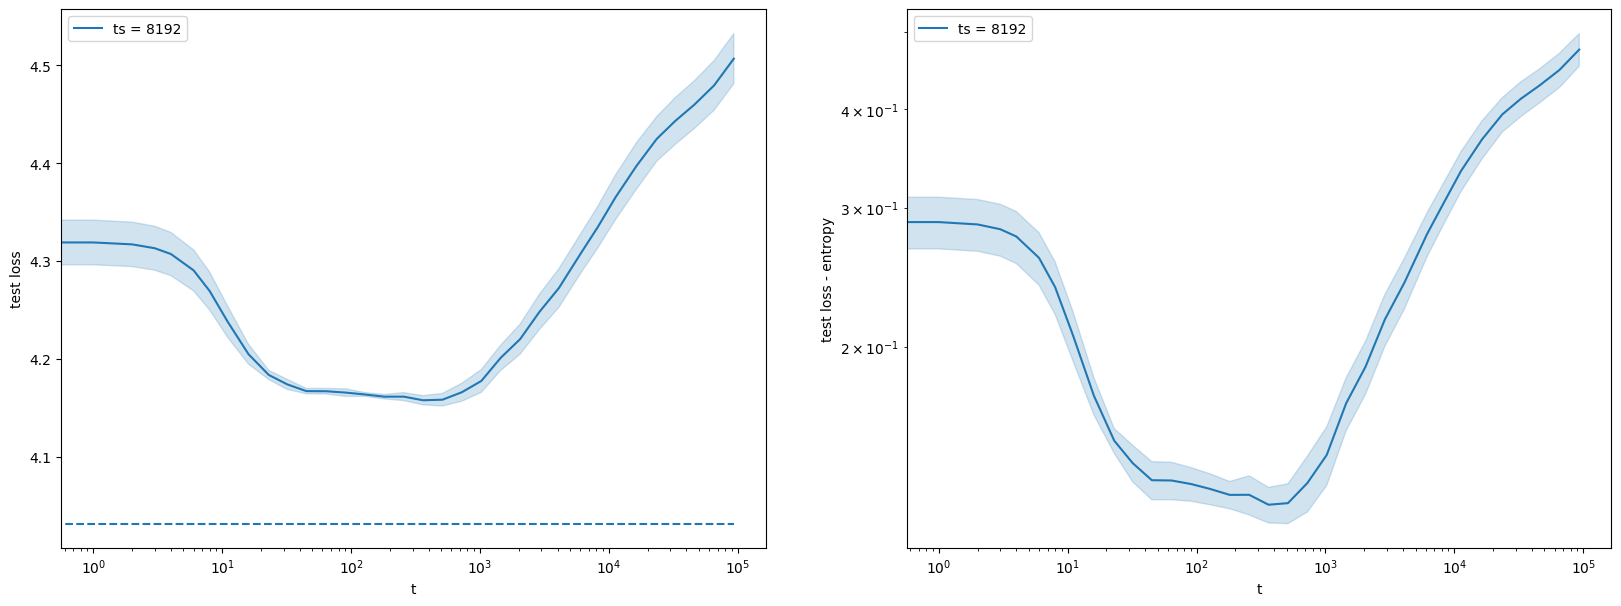

In [19]:
# Parámetros básicos
beta_list =[0.9,1.0,1.1]                 # Valores β
beta_value = beta_list[0]                  #Seleccionamos beta
nexp = 8                                   # Experimentos
path = 'RLM_results/mt/'
training_values =[2**13]           # lista de ts a comparar; 
batch_size= 64
nh=1
emb_dim = 128


# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

for i_ts, train_size in enumerate(training_values):
    # Prefijo del nombre de archivo siguiendo tu convención
    prefix = f'rlm_64L1_b{beta_value}_ts{train_size}_{batch_size}_{nh}_{emb_dim}_'

    # Acumuladores por run
    t_list = []      # tiempos por run (vector)
    tl_list = []     # test loss por run (vector)
    ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
    diff_list = []   # (test loss − entropy) por run (vector)

    # Recorremos runs 1..nexp
    for i in range(1, nexp+1):
        # Carga de cada repetición
        # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
        res = torch.load(path + prefix + f'{i}.pt', map_location='cpu', weights_only=False)

        # Extraemos las series del dict
        dyn = res['output']['dynamics']     # lista de dicts por paso temporal
        ent = res['output']['entropy']      # escalar o serie (según cómo se guardó)

        # Convertimos a arrays NumPy para promediar
        t = np.asarray([d['t'] for d in dyn], dtype=float)
        tl = np.asarray([d['testloss'] for d in dyn], dtype=float)

        # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
        if np.ndim(ent) == 0:
            ent_vec = np.full_like(t, float(ent))
        else:
            ent_vec = np.asarray(ent, dtype=float)[:len(t)]

        # Guardamos cada run
        t_list.append(t)
        tl_list.append(tl)
        ent_list.append(ent_vec)
        diff_list.append(tl - ent_vec)

    # Si no hubo archivos válidos, pasa al siguiente ts
    if not t_list:
        continue

    # Alineamos longitudes: recortamos todas las series a la mínima longitud común L
    L = min(len(x) for x in t_list)
    T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
    TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
    ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
    DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]

    # Estadísticos por paso temporal (promedio y desviación estándar)
    t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
    tl_mean = TL.mean(axis=0)     # test loss promedio
    tl_std  = TL.std(axis=0)      # σ de test loss
    ent_mean = ENT.mean(axis=0)   # entropía promedio
    di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
    di_std  = DI.std(axis=0)      # σ de (test loss − entropy)

    # Color consistente por ts
    c = f'C{i_ts}'
    
    # Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
    ax[0].plot(t_mean, tl_mean, c, label=f'ts = {train_size}')
    ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
    ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')

    # Panel derecho: (test loss − entropy) ±σ
    ax[1].plot(t_mean, di_mean, c, label=f'ts = {train_size}')
    ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()